In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.inspection import permutation_importance
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

In [2]:
model = joblib.load('../app/data/hospital_closure_model.pkl')
test = pd.read_csv('../data/test_data_with_pred.csv')
train = pd.read_csv('../data/train_set.csv')
hospitals_full = pd.read_csv('../data/hospitals_full.csv')
hospitals_master = pd.read_csv('../data/hospitals_master.csv')
surv_functions = pd.read_csv('../data/surv_functions.csv')

/var/folders/51/zgq0lbb14t13h0_bgn8nntnm0000gn/T/ipykernel_91659/2087134432.py:4: DtypeWarning: Columns (67) have mixed types. Specify dtype option on import or set low_memory=False.
  hospitals_full = pd.read_csv('../data/hospitals_full.csv')


In [3]:
test['CCN'] = test['CCN'].astype(int).astype(str).str.zfill(6)

In [4]:
# Merge hospitals master with test data to bring back in identifying characteristics like hospital name
test_full = hospitals_master[['CCN','Facility Name','Prior Name','State','Closure Date']].merge(test, how='right', on='CCN')

In [5]:
test_full.head(2)

,CCN,Facility Name,Prior Name,State,Closure Date,Medicaid charges,STATEMENT OF REVENUES AND EXPENSES: Net Income (G3_C1_29),"ADJUSTED SALARIES, Subtotal Salaries",BALANCE SHEET: Prepaid expenses (G_C1THRU4_8),BED DAYS: Total Hospital,...,Hospital Type_Voluntary non-profit - Church,Hospital Type_Voluntary non-profit - Other,Hospital Type_Voluntary non-profit - Private,General Ownership Type_for-profit,General Ownership Type_govt,General Ownership Type_non-profit,Pred_Closure,Status,Time,Year
0,190044,ACADIA GENERAL HOSPITAL,NaN,LA,NaN,-0.141395,-0.291649,-0.496079,-0.494961,-0.456705,...,0.0,0.0,1.0,0.0,0.0,1.0,-1.948490,False,16.0,2022
1,190044,ACADIA GENERAL HOSPITAL,NaN,LA,NaN,-0.244175,0.035763,-0.464594,-0.445257,-0.456705,...,0.0,0.0,1.0,0.0,0.0,1.0,-3.713724,False,16.0,2023


Looking at survival function dataframe. Each value in the survival functions dataframe captures the probability that the given hospital will survive (remain open) beyond the year in the column.

In [6]:
surv_functions.columns = [2009 + int(float(col)) for col in surv_functions.columns]

In [7]:
surv_functions_full = pd.concat([test_full[['CCN','Facility Name','Year']], surv_functions], axis=1)
surv_functions_full.head(2)

,CCN,Facility Name,Year,2011,2012,2014,2015,2016,2020,2021,2022,2023,2024,2025,2026
0,190044,ACADIA GENERAL HOSPITAL,2022,0.999896,0.999792,0.999688,0.999584,0.999480,0.999063,0.998851,0.998851,0.998851,0.998851,0.998851,0.998851
1,190044,ACADIA GENERAL HOSPITAL,2023,0.999912,0.999824,0.999736,0.999647,0.999559,0.999205,0.999025,0.999025,0.999025,0.999025,0.999025,0.999025


In [8]:
surv_functions_full[surv_functions_full['Year']==2025][['Facility Name',2025]].sort_values(by=2025)

,Facility Name,2025
465,CARILION TAZEWELL COMMUNITY HOSPITAL,0.926604
1600,MARION REGIONAL MEDICAL CENTER,0.987990
940,FAYETTE MEDICAL CENTER,0.996174
1806,MERCY REGIONAL MEDICAL CENTER,0.996644
2959,UNION MEDICAL CENTER,0.996653
...,...,...
1961,NANTUCKET COTTAGE HOSPITAL,0.999268
1295,HUGH CHATHAM MEMORIAL HOSPITAL,0.999270
1686,MCLEOD MEDICAL CENTER - DILLON,0.999273
1065,GRADY GENERAL HOSPITAL,0.999302


Extracting feature coefficients to see exactly how much each feature increases or decreases the log-hazard risk. A positive coefficient indicates a higher risk of hospital closure, while a negative coefficient indicates a protective effect.

In [9]:
feature_cols = [col for col in test.columns if col not in ('CCN','Pred_Closure','Status','Time','Year')]

feature_coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_[:, 20] 
})

# Filter to see only the non-zero selected features
selected_features = feature_coef_df[feature_coef_df['Coefficient'] != 0]

In [10]:
pd.set_option('display.max_colwidth', None)
selected_features.sort_values(by='Coefficient').reset_index()

,index,Feature,Coefficient
0,77,Per Capita Short Term Gen Hosp Admissions,-0.759141
1,114,Hospital Type_Voluntary non-profit - Private,-0.521394
2,66,Dist Hosp By 00 - 39% Util Rate Short Term General Hospitals,-0.198232
3,47,Financial Indicators: SOLVENCY Equity Ratio,-0.157281
4,81,Per Capita Total Medicare Inpatient Days Short Term General Hospitals,-0.144092
5,79,Per Capita Total Active D.O.s Non-Federal,0.135841
6,46,Financial Indicators: SOLVENCY Debt Ratio,0.165347
7,117,General Ownership Type_non-profit,0.377812
8,113,Hospital Type_Voluntary non-profit - Other,0.453485


Looking at the most impactful model features based on permutation importance scores. 

To evaluate the model performance, I'll use concordance_index_censored, which measures how accurately the model ranks hospitals by their risk of closure over time.

Permutation feature importance will measure how much the model's concordance_index_censored score drops when the values of a single feature are randomly shuffled.

In [42]:
feature_cols = [col for col in test.columns if col not in ('CCN','Closure Proximity','Status','Time','Pred_Closure','Year')]
X_test = test[feature_cols]
X_train = train[feature_cols]
y_test = test[['Status','Time']]

def c_index_scorer(model, X, y):
    predictions = model.predict(X)
    
    event_indicator = y_test['Status']
    event_time = y_test['Time']
    
    c_index, _, _, _, _ = concordance_index_censored(event_indicator, event_time, predictions)
    
    return c_index

# Permutation importance applied to the CoxnetSurvivalAnalysis model
feature_importances = permutation_importance(
    model, 
    X_test.to_numpy(), 
    Surv.from_arrays(y_test['Status'], y_test['Time']),
    random_state=0, 
    scoring=c_index_scorer,
    n_repeats=5 
)

# Create the results DataFrame
top_features_df = pd.DataFrame({
    'Feature': feature_cols,
    'Score': feature_importances['importances_mean']
}).sort_values('Score', ascending=False)

In [47]:
top_features_df.head()

,Feature,Score
114,Hospital Type_Voluntary non-profit - Private,0.130924
77,Per Capita Short Term Gen Hosp Admissions,0.053098
101,Metro_Status_Neither,0.032803
63,recommend_score,0.029000
2,"ADJUSTED SALARIES, Subtotal Salaries",0.026350


In [46]:
top_features_df.sort_values('Score', ascending=True).head()

,Feature,Score
53,rrate,-0.027218
64,understood_score,-0.025671
98,RUCA_10.0,-0.017936
66,Dist Hosp By 00 - 39% Util Rate Short Term General Hospitals,-0.014772
91,RUCA_4.0,-0.010322


Investigating SHAP values. In this context, since we are using predict_survival_function as the scoring method, each SHAP value represents the amount a specific feature’s value pushes the survival probability up or down relative to the baseline probability that a hospital will close.

Note: While a final probability is constrained between 0 and 1, an individual feature's SHAP value can exceed these bounds (e.g., a single feature might push the risk up by 1.5). This happens because SHAP measures a feature's average marginal contribution, and interactions with other features dictate the final, bounded output.

In [14]:
# Fixed time point will be 2025 (final year in the dataset)
time_horizon = 16.0 # years since 2010 (first year in the dataset), including 2010

def predict_survival_prob(X_input):
    # Get the list of survival functions for all samples
    surv_funcs = model.predict_survival_function(X_input)
    
    # Evaluate each step function at the specific year of interest (2025)
    # This gives us a 1D array of probabilities between 0 and 1
    probabilities = np.array([func(time_horizon) for func in surv_funcs])
    return probabilities


In [15]:
# Sample the train data for faster runtime
X_train_summary = shap.sample(X_train.to_numpy(), nsamples=50)

# Pass the sampled train data to the explainer
explainer = shap.KernelExplainer(predict_survival_prob, X_train_summary)

# Compute SHAP values for test data
shap_values = explainer.shap_values(X_test.to_numpy())

  0%|          | 0/3310 [00:00<?, ?it/s]

In [16]:
exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test.values,
    feature_names=feature_cols
)

In [17]:
shap_df = pd.DataFrame(shap_values, columns=feature_cols)

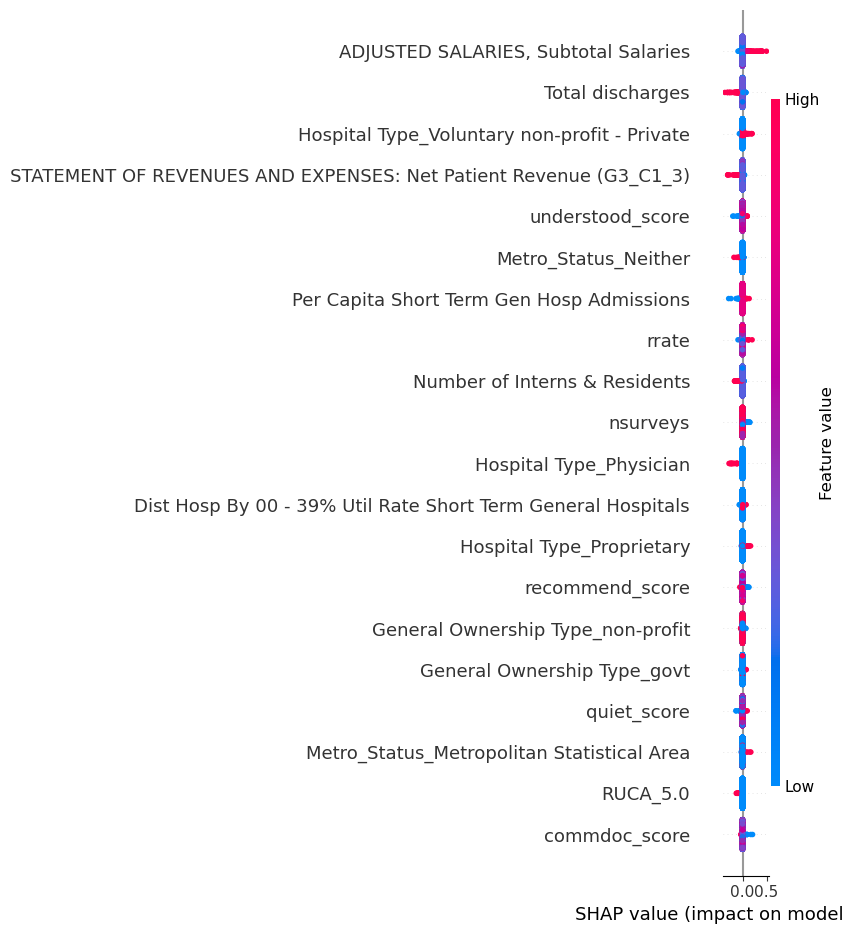

In [18]:
shap.summary_plot(shap_values, X_test)

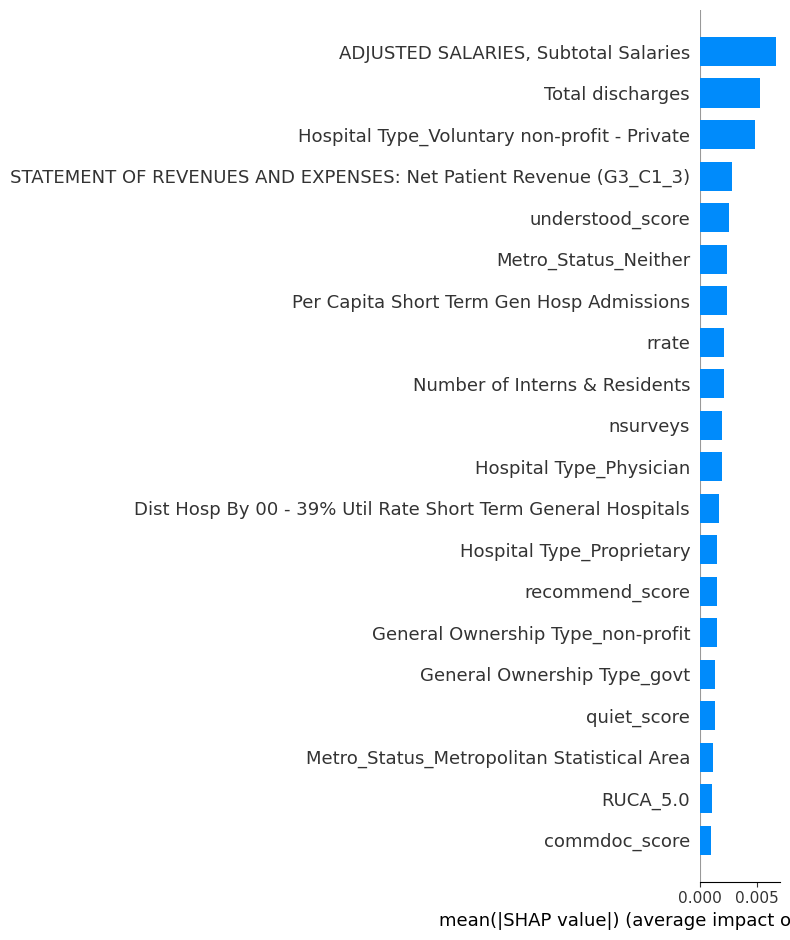

In [19]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

Calculating SHAP values based on risk score rather than probability:

In [50]:
# Sample the train data for faster runtime
X_train_summary = shap.sample(X_train.to_numpy(), nsamples=50)

# Pass the sampled train data to the explainer
explainer = shap.KernelExplainer(model.predict, X_train_summary)

# Compute SHAP values for test data
shap_values = explainer.shap_values(X_test.to_numpy())

  0%|          | 0/3310 [00:00<?, ?it/s]

In [51]:
exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test.values,
    feature_names=feature_cols
)

In [52]:
shap_df = pd.DataFrame(shap_values, columns=feature_cols)

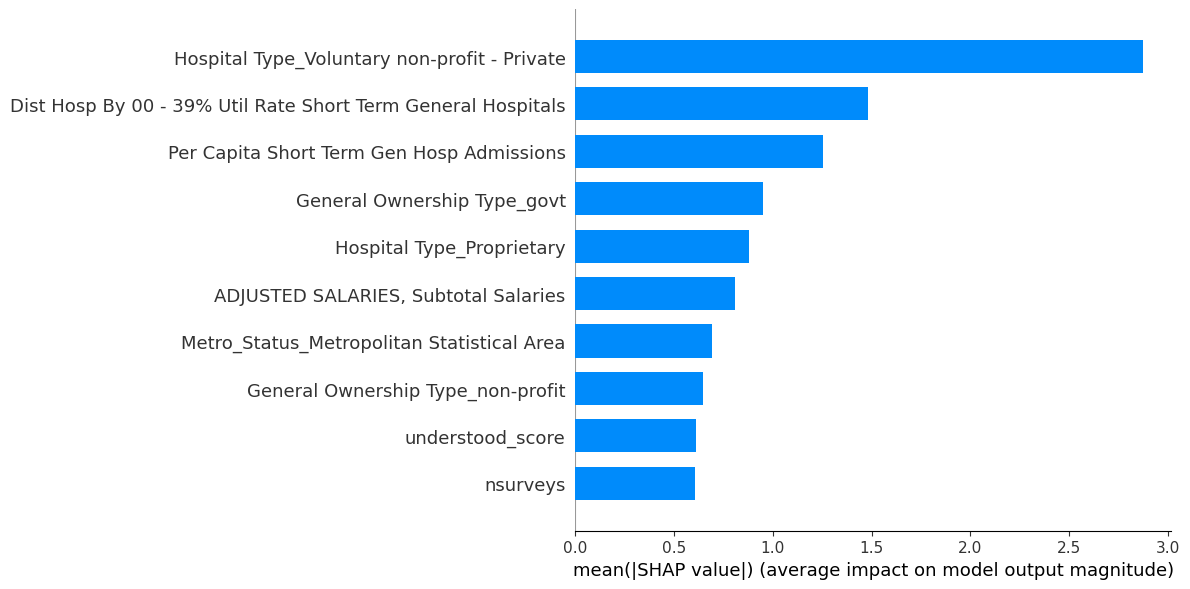

In [72]:
plt.figure(figsize=(12,6))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=10, show=False, plot_size=None)
plt.tight_layout()
plt.savefig("./app/images/shap_summary_bar_plot.png", bbox_inches="tight", dpi=300)

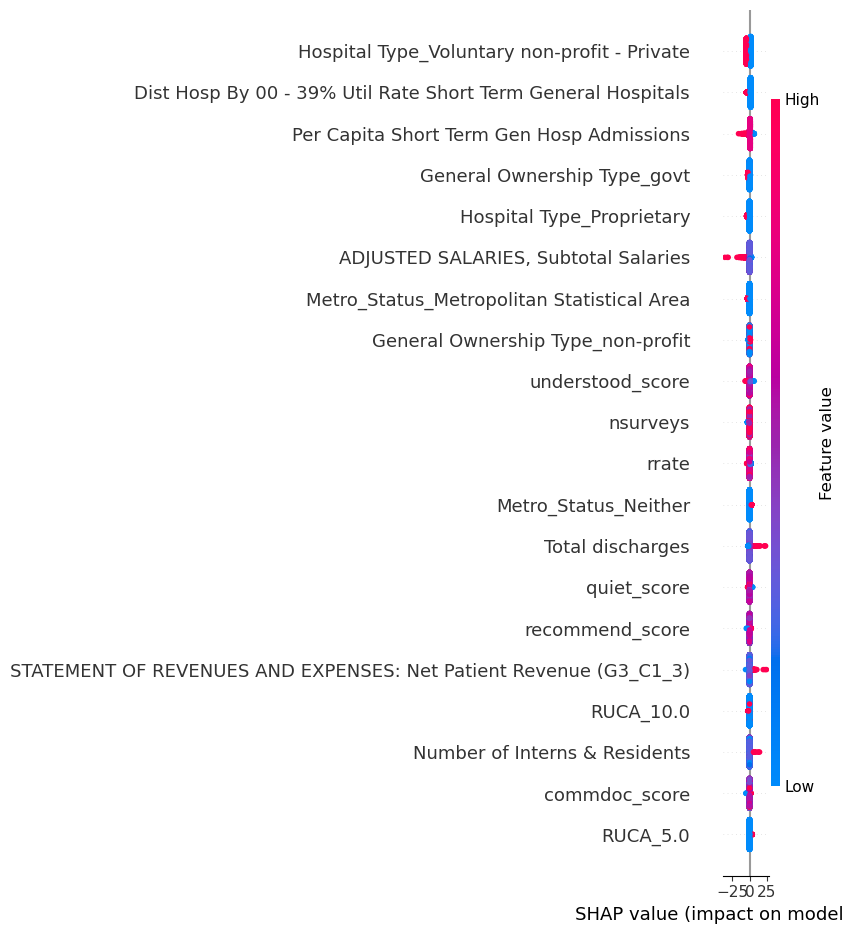

In [55]:
shap.summary_plot(shap_values, X_test)

Case Studies:

Hospitals with the highest chance of closing, per our model:

In [20]:
test_full[['Facility Name','Pred_Closure','Year','Status','Time']].sort_values(by='Pred_Closure',ascending=False).head(5)

,Facility Name,Pred_Closure,Year,Status,Time
139,ASPIRUS ONTONAGON HOSPITAL,15.350797,2023,False,15.0
759,COVENANT HEALTH HOBBS HOSPITAL,14.677029,2024,False,16.0
2739,ST. MARK'S MEDICAL CENTER,14.666117,2023,True,14.0
1607,MARSHFIELD MEDICAL CENTER,14.040147,2024,False,16.0
1719,MEMORIAL HEALTHCARE,13.969889,2022,False,16.0


Identifying good case studies based on facilities with the highest variance in their risk scores:

In [21]:
test_full.groupby(['CCN','Facility Name'])['Pred_Closure'].var().nlargest(5)

CCN     Facility Name                     
180024  SPRING VIEW HOSPITAL                  16993.395375
390006  GEISINGER MEDICAL CENTER                137.024952
230259  CHELSEA HOSPITAL                        129.022182
180044  PIKEVILLE MEDICAL CENTER                109.928791
180029  HAZARD ARH REGIONAL MEDICAL CENTER       96.205688
Name: Pred_Closure, dtype: float64

In [22]:
test_full[test_full['Facility Name']=='HAZARD ARH REGIONAL MEDICAL CENTER'][['Facility Name','Year','Pred_Closure']].sort_values(by='Year')

,Facility Name,Year,Pred_Closure
1186,HAZARD ARH REGIONAL MEDICAL CENTER,2022,-14.736126
1187,HAZARD ARH REGIONAL MEDICAL CENTER,2023,-13.408360
1188,HAZARD ARH REGIONAL MEDICAL CENTER,2024,2.883129
1189,HAZARD ARH REGIONAL MEDICAL CENTER,2025,2.897920


#### SHAP plots:

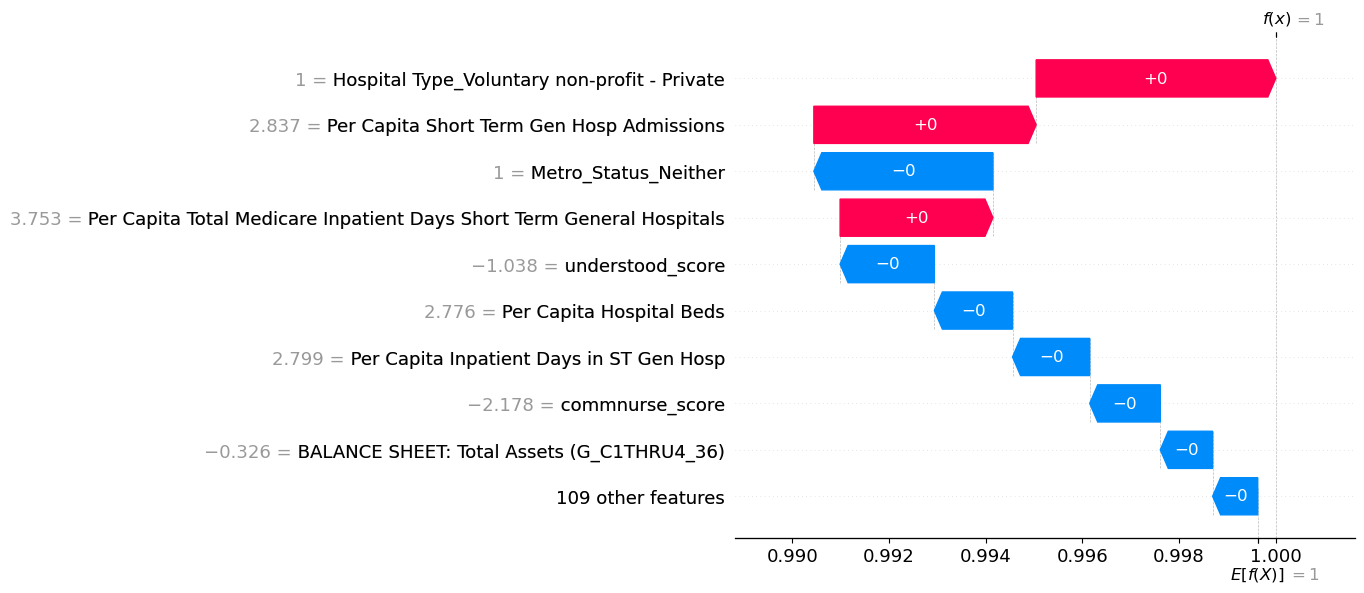

In [23]:
shap.plots.waterfall(exp[1186])

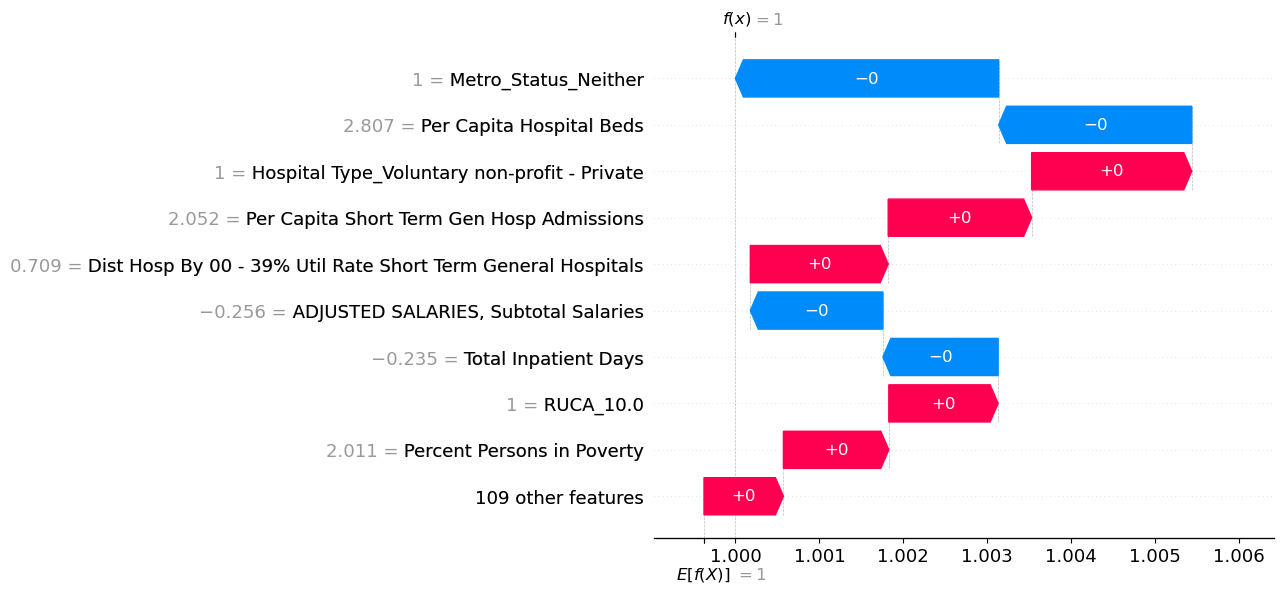

In [24]:
shap.plots.waterfall(exp[1187])

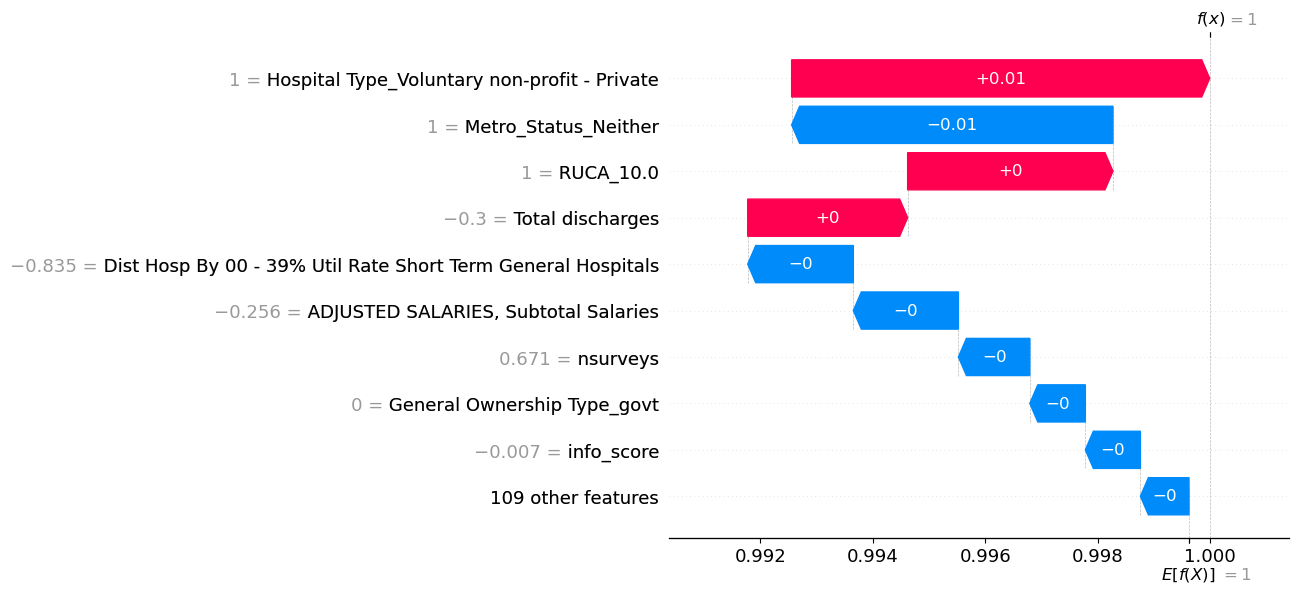

In [25]:
shap.plots.waterfall(exp[1188])

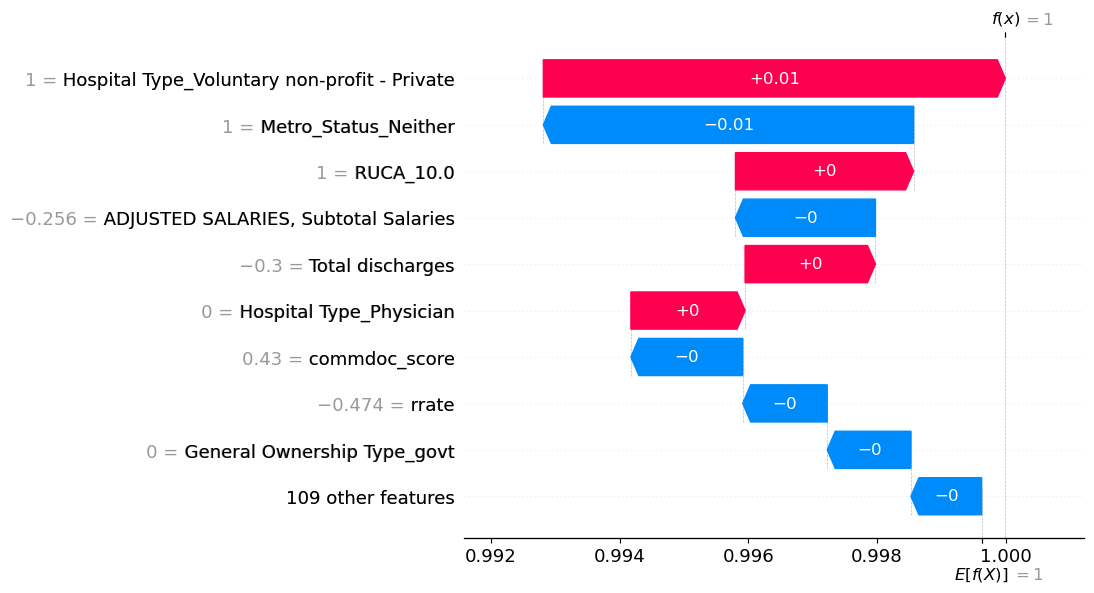

In [26]:
shap.plots.waterfall(exp[1189])

#### 

In [27]:
test_full[test_full['Facility Name']=='CHELSEA HOSPITAL'][['Facility Name','Year','Pred_Closure']].sort_values(by='Year')

,Facility Name,Year,Pred_Closure
526,CHELSEA HOSPITAL,2022,-21.777577
527,CHELSEA HOSPITAL,2023,-22.399512
528,CHELSEA HOSPITAL,2024,-2.270398
529,CHELSEA HOSPITAL,2025,-2.570804


In [28]:
test_full[test_full['Facility Name']=='COVENANT HEALTH HOBBS HOSPITAL'][['Facility Name','Year','Pred_Closure']].sort_values(by='Year')

,Facility Name,Year,Pred_Closure
757,COVENANT HEALTH HOBBS HOSPITAL,2022,1.322821
758,COVENANT HEALTH HOBBS HOSPITAL,2023,5.651393
759,COVENANT HEALTH HOBBS HOSPITAL,2024,14.677029
760,COVENANT HEALTH HOBBS HOSPITAL,2025,0.940792


Finding a hospital that closed that could be a good case study:

In [29]:
test_full[test_full['Status']==True].groupby(['CCN','Facility Name'])['Pred_Closure'].agg(lambda x: x.max() - x.min()).nlargest(5)

CCN     Facility Name                               
051306  GLENN MEDICAL CENTER                            0.0
140040  GALESBURG COTTAGE HOSPITAL                      0.0
140143  ST. MARGARET'S HEALTH - SPRING VALLEY           0.0
151302  INDIANA UNIVERSITY HEALTH BLACKFORD HOSPITAL    0.0
151335  ASCENSION ST. VINCENT DUNN                      0.0
Name: Pred_Closure, dtype: float64

In [30]:
test_full[test_full['Status']==True][['Facility Name','Year','Pred_Closure']].sort_values(by='Pred_Closure',ascending=False).head(5)

,Facility Name,Year,Pred_Closure
2739,ST. MARK'S MEDICAL CENTER,2023,14.666117
1049,GLENN MEDICAL CENTER,2025,12.271696
361,BLESSING HEALTH KEOKUK,2022,11.788953
1817,MERCYONE PRIMGHAR MEDICAL CENTER,2024,10.881164
1325,INDIANA UNIVERSITY HEALTH BLACKFORD HOSPITAL,2023,9.904977


In [83]:
test_full[test_full['Facility Name']=='COVENANT HEALTH HOBBS HOSPITAL'][['Year','Pred_Closure','Financial Indicators: SOLVENCY Debt Ratio']]

,Year,Pred_Closure,Financial Indicators: SOLVENCY Debt Ratio
757,2022,1.322821,0.196629
758,2023,5.651393,4.877025
759,2024,14.677029,15.959346
760,2025,0.940792,-0.211056


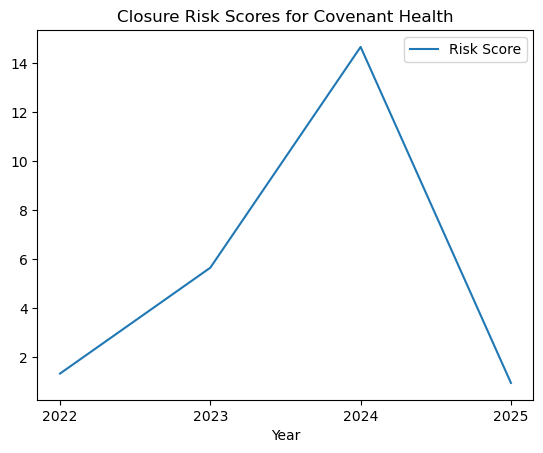

In [99]:
test_full[test_full['Facility Name']=='COVENANT HEALTH HOBBS HOSPITAL'].plot(kind='line',x='Year',y='Pred_Closure')
plt.title('Closure Risk Scores for Covenant Health')
plt.xticks([2022, 2023, 2024, 2025])
plt.legend(['Risk Score'])
plt.savefig("./app/images/covenant_scores.png", bbox_inches="tight", dpi=300)
plt.show()

In [100]:
# COVENANT HEALTH HOBBS HOSPITAL in 2024
shap.plots.waterfall(exp[759],show=False)
plt.savefig("./app/images/covenant_health_hobbs_2024.png", bbox_inches="tight", dpi=300)

In [105]:
# COVENANT HEALTH HOBBS HOSPITAL in 2025
shap.plots.waterfall(exp[760],show=False)
plt.savefig("./app/images/covenant_health_hobbs_2025.png", bbox_inches="tight", dpi=300)